In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KernelDensity


In [3]:
df = pd.read_csv("../Cleaned_again.csv")

In [4]:

df[df["Exposure"] > 1]

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density


In [5]:
df[df["ClaimNb"] > 4]

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
88194,6,0.33,4,12,52,50,824
186937,11,0.07,4,13,53,50,824
192291,5,0.08,4,12,52,50,824
197358,5,1.00,7,9,67,50,4762
327456,11,1.00,5,6,65,50,13
386950,9,0.08,4,12,52,50,824


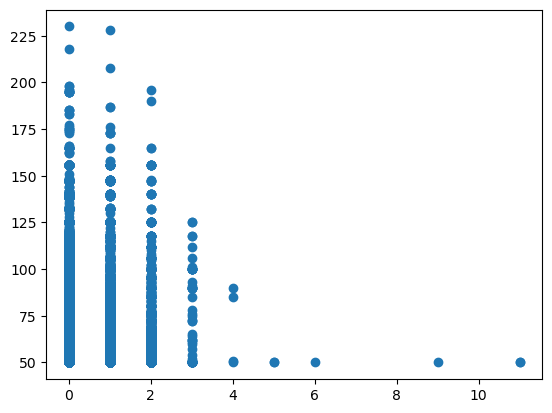

In [7]:
plt.scatter(df["ClaimNb"], df["BonusMalus"])

In [17]:
claim = 0
claims = df[df["ClaimNb"] == claim]
num1 = 18
num2 = 28
for i in range(9):
    int1 = num1 + i * 10
    int2 = num2 + i * 10
    interval = claims[(claims["DrivAge"] > int1) & (claims["DrivAge"] < int2)]
    amount_claims = len(interval)
    interval_total = df[(df["DrivAge"] > int1) & (df["DrivAge"] < int2)]
    total = len(interval_total)
    print(f"Between {int1} and {int2} there is {amount_claims/total * 100}% percent who has {claim} claims.")


Between 18 and 28 there is 93.99522276456538% percent who has 0 claims.
Between 28 and 38 there is 95.87780329640637% percent who has 0 claims.
Between 38 and 48 there is 95.0449739624428% percent who has 0 claims.
Between 48 and 58 there is 94.6991649740465% percent who has 0 claims.
Between 58 and 68 there is 95.09124879687471% percent who has 0 claims.
Between 68 and 78 there is 93.9294839039346% percent who has 0 claims.
Between 78 and 88 there is 93.27855603448276% percent who has 0 claims.
Between 88 and 98 there is 93.51351351351352% percent who has 0 claims.
Between 98 and 108 there is 90.74074074074075% percent who has 0 claims.


<Axes: xlabel='DrivAge', ylabel='Density'>

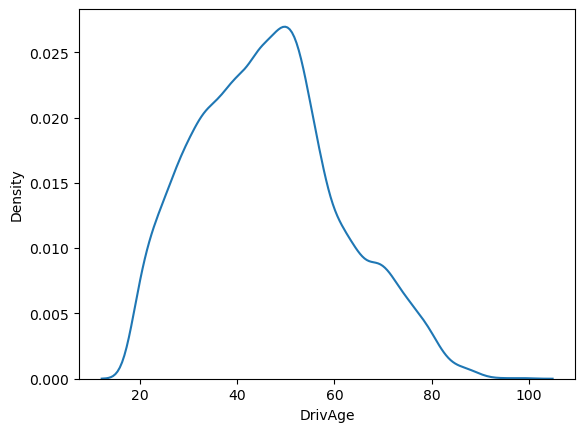

In [11]:
distr = df[df["ClaimNb"] == 1]
sns.kdeplot(distr["DrivAge"])

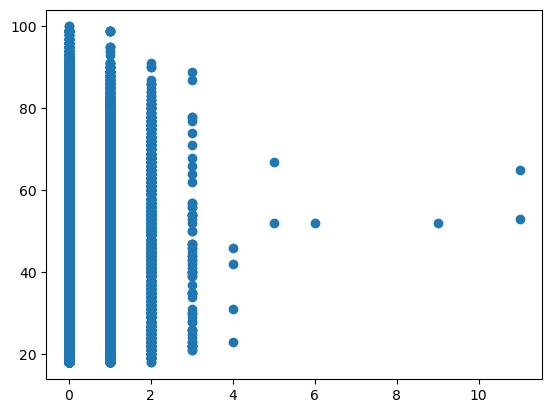

In [19]:
plt.scatter(df["ClaimNb"], df["DrivAge"])
plt.show()

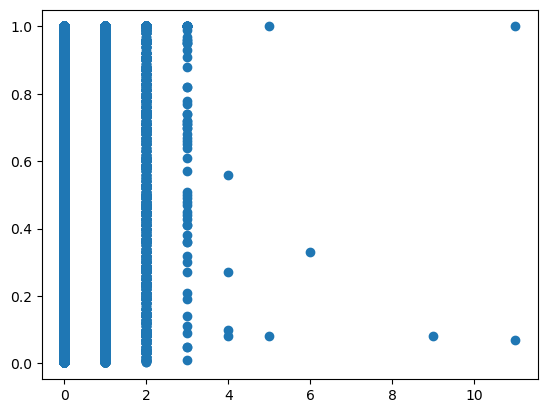

In [20]:
plt.scatter(df["ClaimNb"], df["Exposure"])

<Axes: ylabel='ClaimNb'>

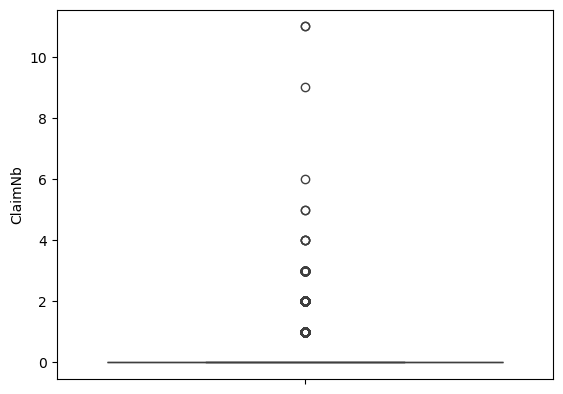

In [17]:
sns.boxplot(df["ClaimNb"])

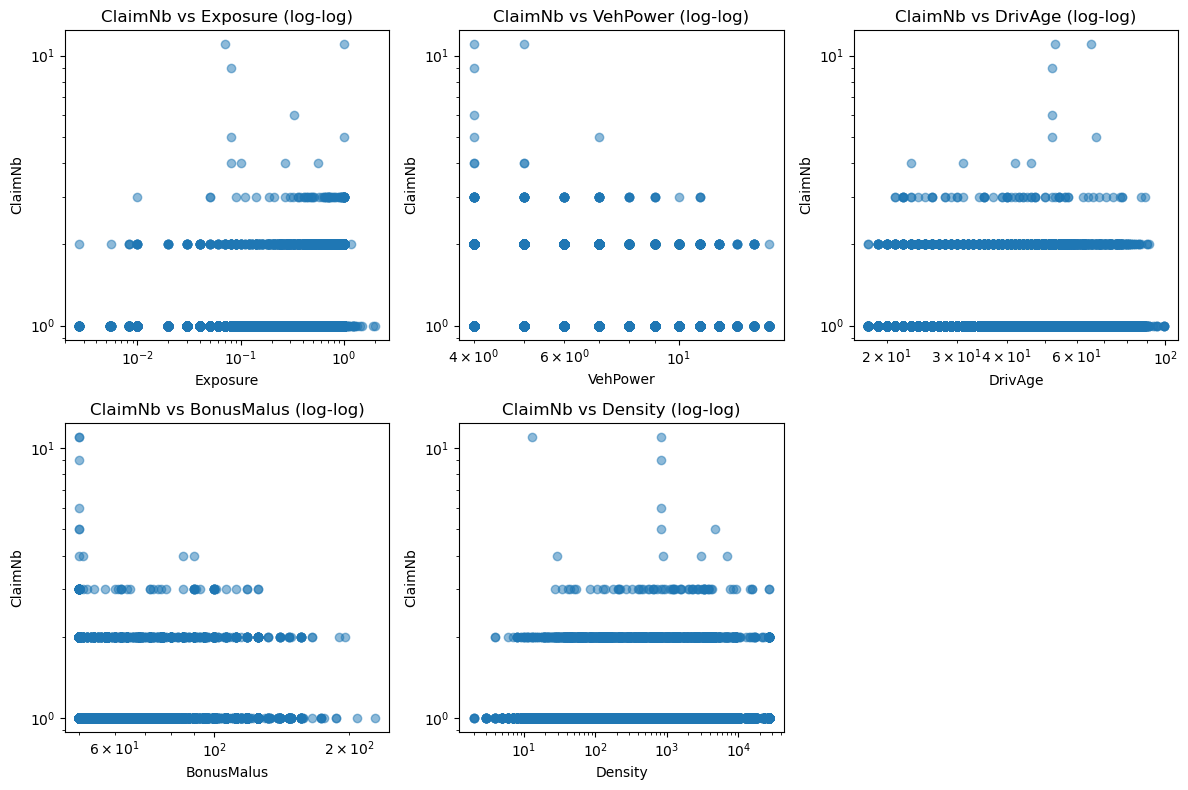

In [18]:
cols = ['Exposure', 'VehPower', 'DrivAge', 'BonusMalus', 'Density']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    
    # Filter out zero or negative values (log cannot handle them)
    mask = (df['ClaimNb'] > 0) & (df[col] > 0)
    
    plt.scatter(df.loc[mask, col], df.loc[mask, 'ClaimNb'], alpha=0.5)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(col)
    plt.ylabel('ClaimNb')
    plt.title(f'ClaimNb vs {col} (log-log)')

plt.tight_layout()
plt.show()

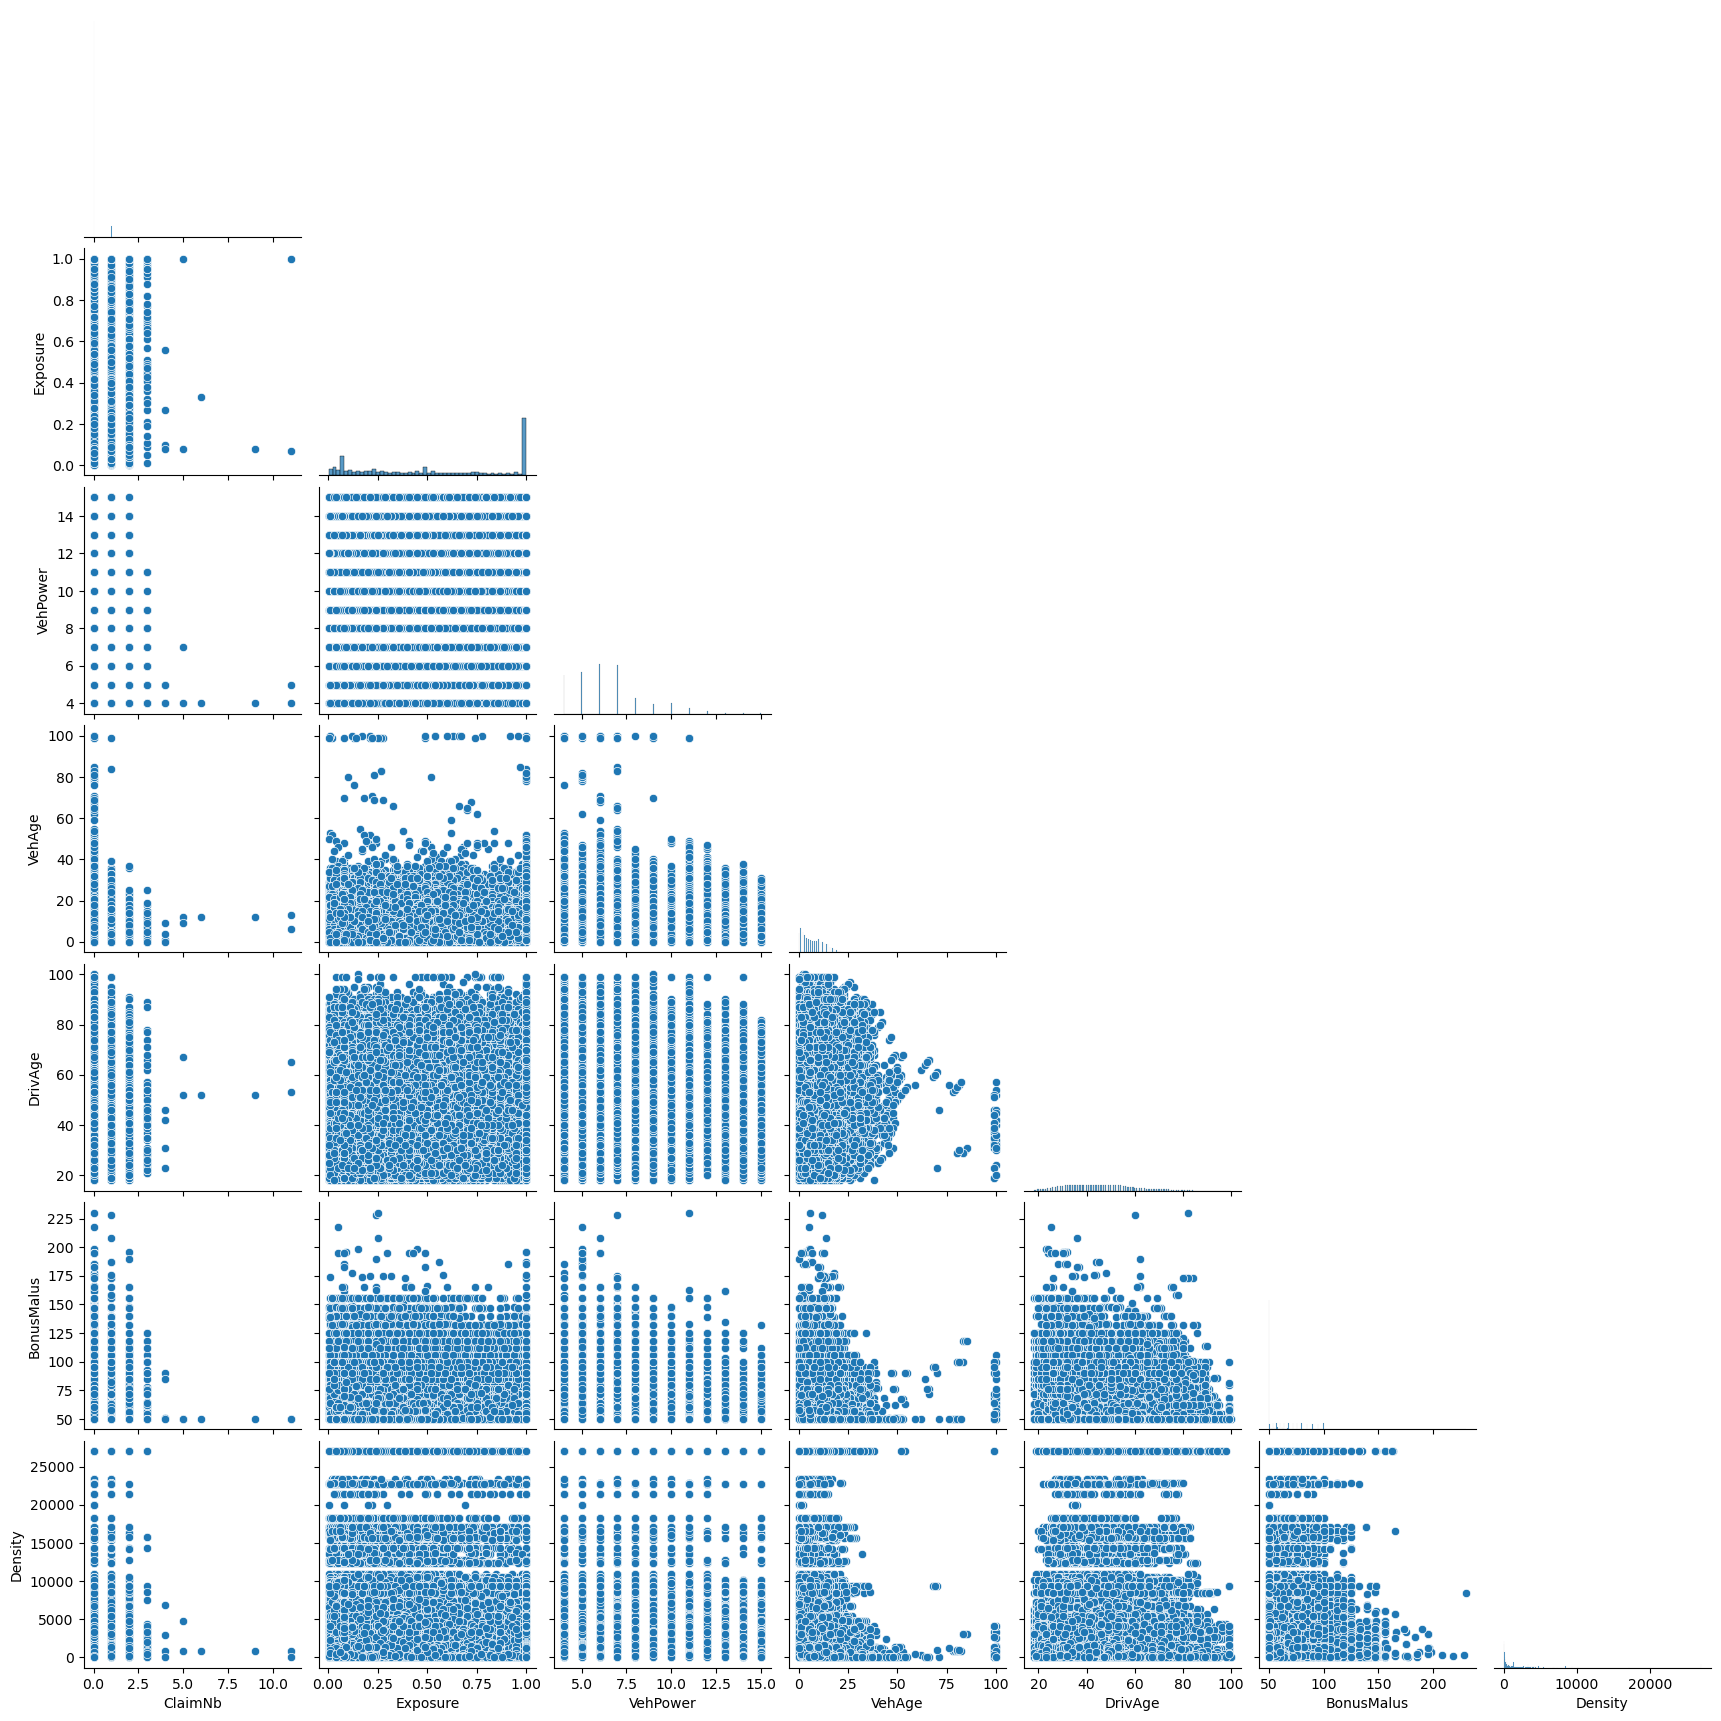

In [21]:
sns.pairplot(df, corner=True)

In [ ]:
sns.displot(
    df, x="ClaimNb", y="DrivAge",
    kind="kde", rug=True
)

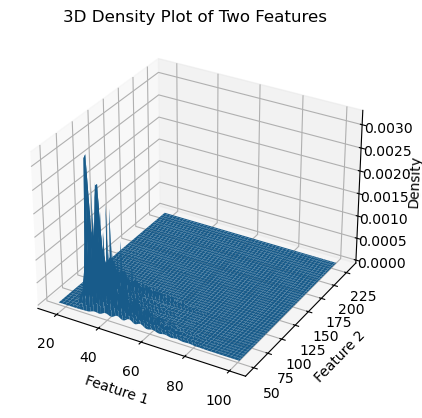

In [5]:
x = df["DrivAge"]
y = df["BonusMalus"]

# Stack into 2-column array (needed for KDE)
data = np.vstack([x, y]).T

# Fit KDE
kde = KernelDensity(bandwidth=0.3, kernel='gaussian')
kde.fit(data)

# Create grid for evaluation
x_grid = np.linspace(x.min()-1, x.max()+1, 100)
y_grid = np.linspace(y.min()-1, y.max()+1, 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid_points = np.vstack([X.ravel(), Y.ravel()]).T

# Evaluate log density and convert to density
Z = np.exp(kde.score_samples(grid_points))
Z = Z.reshape(X.shape)

# Plot 3D density surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z)  # no colors specified per instruction

ax.set_title("3D Density Plot of Two Features")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Density")

plt.show()

In [6]:
df_claims = df[df["ClaimNb"] > 1]
df_claims

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
64,2,1.00,7,1,50,50,511
222,2,1.00,6,7,54,50,19
512,2,0.28,6,1,48,50,175
524,2,0.09,10,0,64,50,99
583,2,1.00,6,11,57,50,9
...,...,...,...,...,...,...,...
539324,2,1.00,7,6,45,50,1457
539736,2,1.00,7,10,52,50,1273
539819,2,0.52,4,14,20,95,64
540274,2,1.00,11,8,61,50,3386


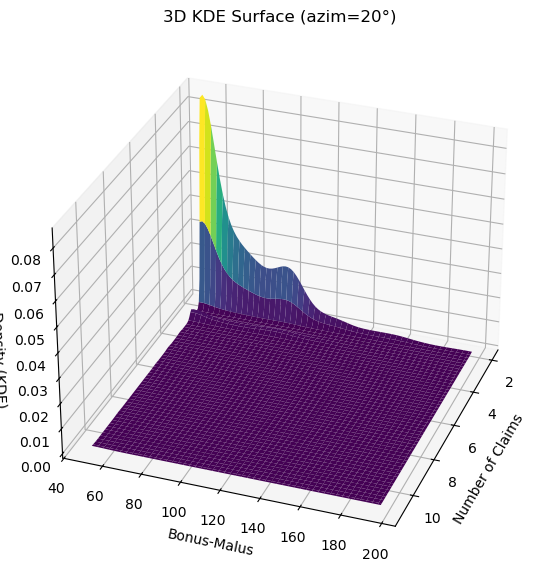

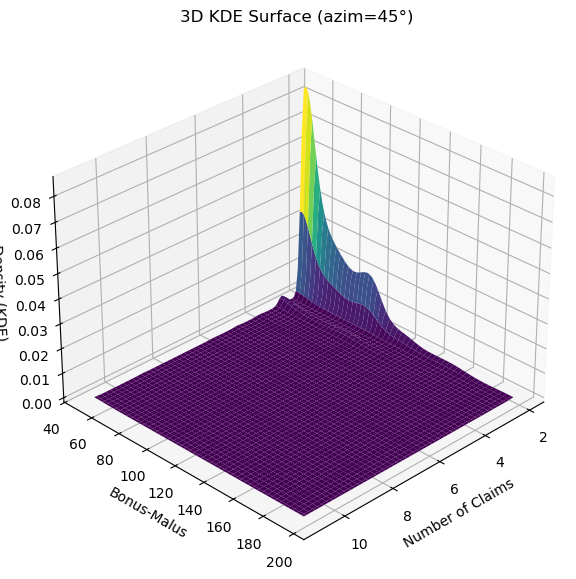

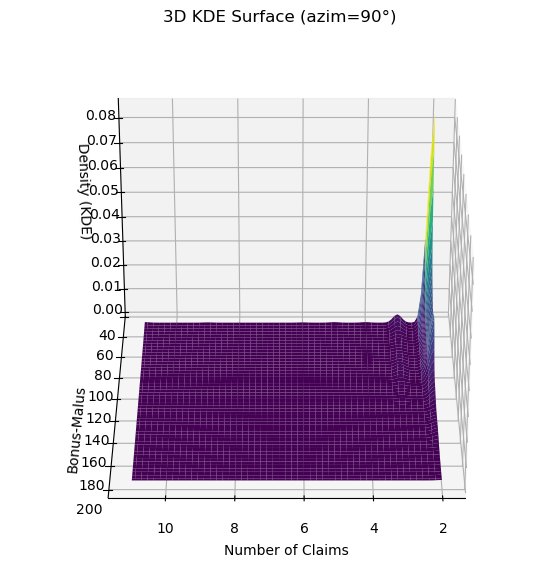

In [7]:
from scipy.stats import gaussian_kde

#Data
x = df_claims["ClaimNb"].values
y = df_claims["BonusMalus"].values

#Grid for KDE
xi, yi = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
positions = np.vstack([xi.ravel(), yi.ravel()])

#KDE estimation
kernel = gaussian_kde(np.vstack([x, y]))
zi = np.reshape(kernel(positions), xi.shape)

#Plot same surface from different angles
angles = [20,45,90]
for angle in angles:
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(xi, yi, zi, cmap='viridis', linewidth=0, antialiased=True)
    ax.set_xlabel("Number of Claims")
    ax.set_ylabel("Bonus-Malus")
    ax.set_zlabel("Density (KDE)")

    ax.view_init(elev=30, azim=angle)
    plt.title(f"3D KDE Surface (azim={angle}°)")
    plt.show()

In [9]:
lowMalus_claims = df[(df["BonusMalus"] < 100) & (df["ClaimNb"] > 0)]
lowMalus_claims

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
36,1,0.78,4,3,50,50,4128
64,2,1.00,7,1,50,50,511
84,1,0.06,4,0,52,55,5433
88,1,0.08,6,2,49,95,824
97,1,1.00,6,6,44,62,10
...,...,...,...,...,...,...,...
541288,1,0.91,11,5,56,50,461
541309,1,0.56,5,11,24,95,763
541369,1,1.00,10,9,89,50,91
541370,1,0.09,7,4,37,82,1326


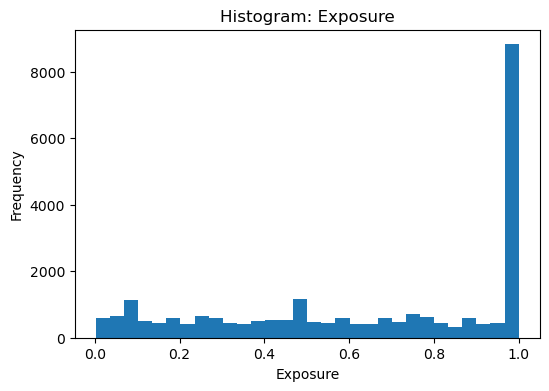

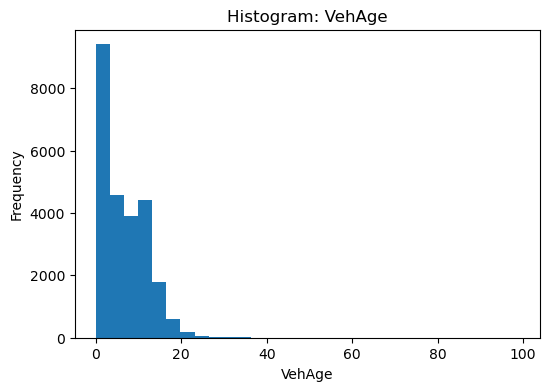

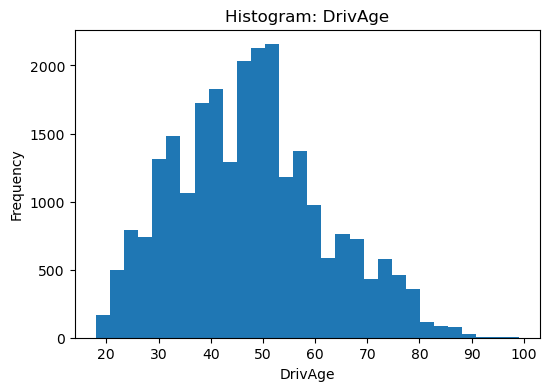

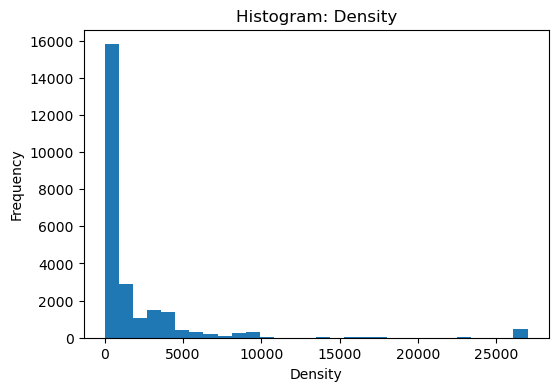

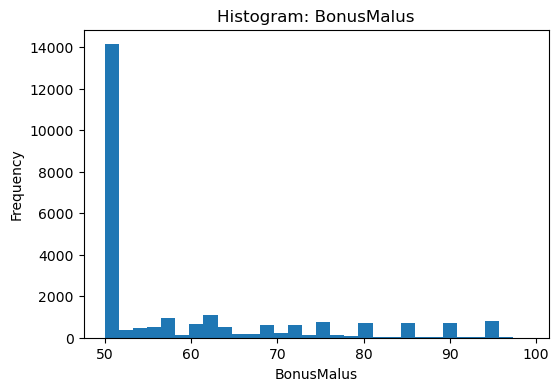

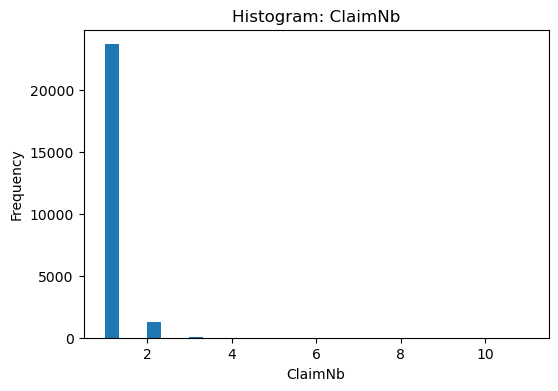

In [13]:
features = ["Exposure", "VehAge", "DrivAge", "Density", "BonusMalus", "ClaimNb"]

for feature in features:
    plt.figure(figsize=(6,4))
    
    plt.hist(lowMalus_claims[feature], bins=30)
    
    plt.title(f"Histogram: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.show()

In [9]:
Claims_1 = df[df["ClaimNb"] == 1]

print(len(Claims_1))
print(len(df))

print(len(Claims_1)/len(df))


25679
541416
0.047429333451541884


In [20]:
claims = df[df["ClaimNb"] > 0]
claims


,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
36,1,0.78,4,3,50,50,4128
64,2,1.00,7,1,50,50,511
84,1,0.06,4,0,52,55,5433
88,1,0.08,6,2,49,95,824
97,1,1.00,6,6,44,62,10
...,...,...,...,...,...,...,...
541330,1,0.66,7,9,26,100,26
541369,1,1.00,10,9,89,50,91
541370,1,0.09,7,4,37,82,1326
541377,1,0.24,9,0,69,50,27000


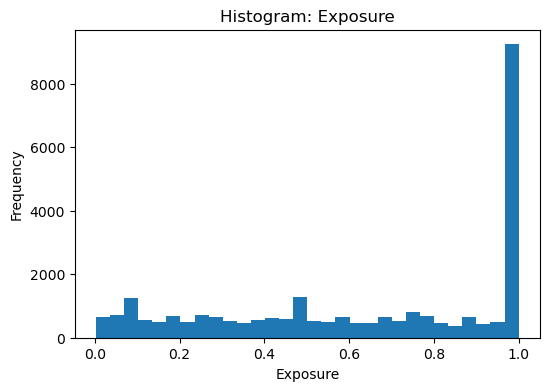

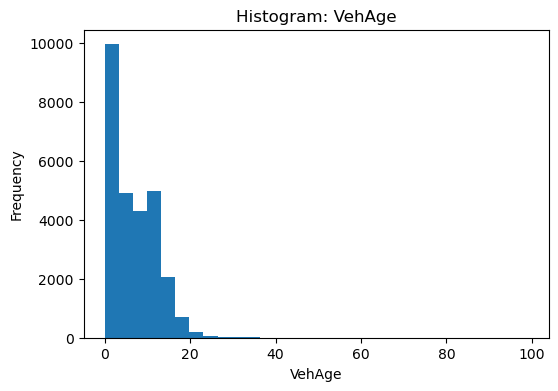

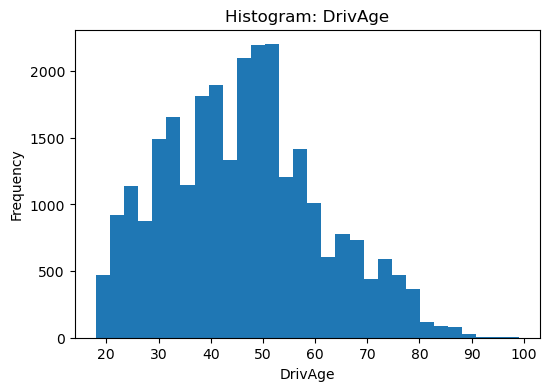

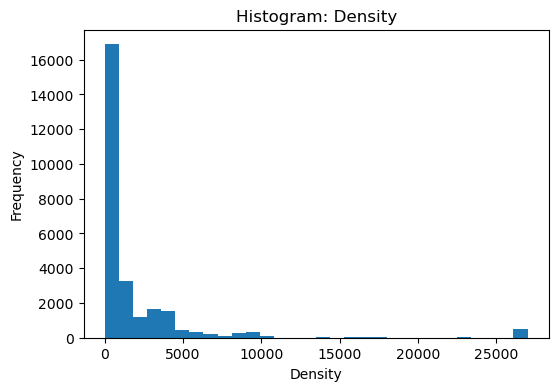

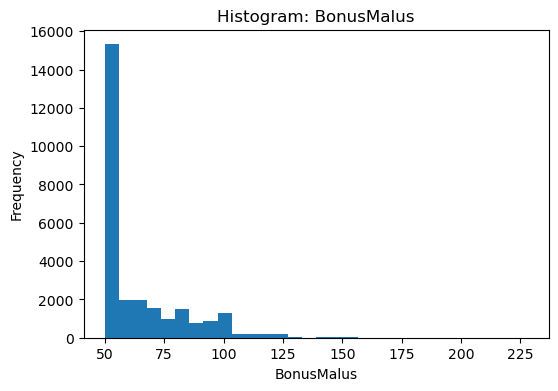

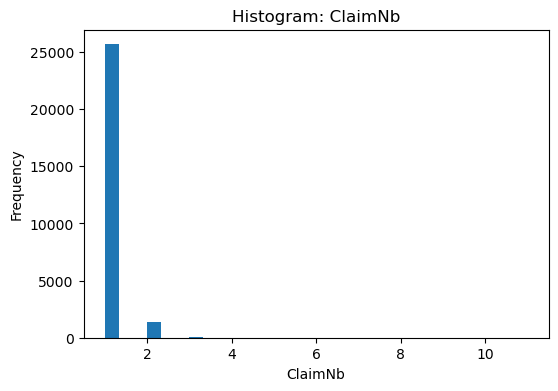

In [21]:
features = ["Exposure", "VehAge", "DrivAge", "Density", "BonusMalus", "ClaimNb"]

for feature in features:
    plt.figure(figsize=(6,4))
    
    plt.hist(claims[feature], bins=30)
    
    plt.title(f"Histogram: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.show()